# 08 - Machine Learning - Classification

## Objective

This notebook develops machine learning models to predict air quality using the feature-engineered AirIntel dataset.

The objectives are:

- Build classification models to predict AQI Category.
- Compare baseline and advanced machine learning algorithms.
- Evaluate model performance using appropriate metrics.
- Save trained models and prediction results for further analysis.

This notebook focuses on model development, while detailed comparison and explainability will be covered in subsequent notebooks.

In [1]:
# Import required libraries

# Suppress warnings
import warnings
warnings.filterwarnings("ignore")

# File handling
from pathlib import Path

# Numerical computing
import numpy as np

# Data manipulation
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import (
    train_test_split,
    KFold,
    StratifiedKFold,
    cross_val_score
)

import time

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder,
    LabelEncoder
)

# Classification Models
from sklearn.dummy import DummyClassifier

from sklearn.linear_model import LogisticRegression

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import (
    RandomForestClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier,
    HistGradientBoostingClassifier
)

from sklearn.neighbors import KNeighborsClassifier

from sklearn.naive_bayes import GaussianNB

from xgboost import XGBClassifier

from lightgbm import LGBMClassifier

# Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    balanced_accuracy_score,
    classification_report,
    ConfusionMatrixDisplay
)

# Model Saving
import joblib

In [2]:
# Project paths

PROJECT_DIR = Path("../")

DATA_DIR = PROJECT_DIR / "data"

MODEL_DIR = PROJECT_DIR / "models"

REPORT_DIR = PROJECT_DIR / "reports"

TABLE_DIR = REPORT_DIR / "tables"

FIGURE_DIR = REPORT_DIR / "figures" / "machine_learning" / "classification"

MODEL_DIR.mkdir(
    parents=True,
    exist_ok=True
)

TABLE_DIR.mkdir(
    parents=True,
    exist_ok=True
)

FIGURE_DIR.mkdir(
    parents=True,
    exist_ok=True
)

In [3]:
# Visualization settings

sns.set_theme(
    style="whitegrid",
    palette="pastel"
)

PALETTE = sns.color_palette("pastel")

RANDOM_STATE = 42

np.random.seed(RANDOM_STATE)

In [4]:
# Load feature engineered dataset

DATA_PATH = DATA_DIR / "processed" / "feature_engineered_airintel.parquet"

df = pd.read_parquet(DATA_PATH)

print(f"Dataset Shape : {df.shape}")

Dataset Shape : (842160, 248)


In [5]:
# Preview dataset

df.head()

,City,State,Latitude,Longitude,Datetime,Year,Month,Day,Hour,Day_of_Week,...,SO2_ugm3_Change,SO2_ugm3_PctChange,O3_ugm3_Change,O3_ugm3_PctChange,PM2_5_ugm3_Volatility_24H,PM10_ugm3_Volatility_24H,CO_ugm3_Volatility_24H,NO2_ugm3_Volatility_24H,SO2_ugm3_Volatility_24H,O3_ugm3_Volatility_24H
0,Agartala,Tripura,23.8315,91.2868,2022-08-05 00:00:00,2022,8,5,0,4,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Agartala,Tripura,23.8315,91.2868,2022-08-05 01:00:00,2022,8,5,1,4,...,0.3,0.111111,1.0,0.031250,0.450000,0.650000,0.500000,1.650000,0.150000,0.500000
2,Agartala,Tripura,23.8315,91.2868,2022-08-05 02:00:00,2022,8,5,2,4,...,0.3,0.100000,1.0,0.030303,0.616441,0.828654,0.471405,2.735365,0.244949,0.816497
3,Agartala,Tripura,23.8315,91.2868,2022-08-05 03:00:00,2022,8,5,3,4,...,0.0,0.000000,-2.0,-0.058824,1.017349,1.408900,0.500000,3.030986,0.248747,0.829156
4,Agartala,Tripura,23.8315,91.2868,2022-08-05 04:00:00,2022,8,5,4,4,...,-0.1,-0.030303,-2.0,-0.062500,1.238386,1.712776,1.095445,3.046572,0.228035,1.326650


In [6]:
print(df.shape)

(842160, 248)


In [7]:
# Dataset information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 842160 entries, 0 to 842159
Columns: 248 entries, City to O3_ugm3_Volatility_24H
dtypes: category(2), datetime64[ns](1), float64(196), int32(4), int64(34), object(11)
memory usage: 1.5+ GB


## Problem Definition

In [8]:
# Define target variables

CLASSIFICATION_TARGET = "AQI_Category"

print("Classification Target :", CLASSIFICATION_TARGET)

Classification Target : AQI_Category


In [9]:
# Remove leakage & pollutant-related columns
leakage_columns = [

    # Targets
    "US_AQI",
    "AQI_Category",
    "EU_AQI",

    "US_AQI_PM25",
    "US_AQI_PM10",
    "US_AQI_NO2",
    "US_AQI_O3",
    "US_AQI_CO",

    "EU_AQI_PM25",
    "EU_AQI_PM10",

    # Date columns
    "Date",
    "Datetime",
    "Day_Name",

    # Raw pollutants
    "PM2_5_ugm3",
    "PM10_ugm3",
    "CO_ugm3",
    "NO2_ugm3",
    "SO2_ugm3",
    "O3_ugm3",
    "Dust_ugm3",
    "AOD",
    "Rain_PM10",

    # Pollution categories
    "PM25_Category_India",
    "Dominant_Pollutant",
    "Humidity_PM25",
    "Wind_PM25",
    "Solar_O3",

    # Pollution engineered features
    "PM_Ratio",
    "Total_Pollution",
    "Mean_Pollution",
    "Maximum_Pollution",
    "Minimum_Pollution",
    "Pollution_Range",
    "Pollution_Count",
    "PM_Difference",
    "CO_NO2_Ratio",
    "PM25_NO2_Ratio",
    "O3_NO2_Ratio",
]

In [10]:
# Remove pollutant-derived temporal features

pollutants = [
    "PM2_5_ugm3",
    "PM10_ugm3",
    "CO_ugm3",
    "NO2_ugm3",
    "SO2_ugm3",
    "O3_ugm3"
]

patterns = [
    "_Lag_",
    "_Rolling",
    "_EMA_",
    "_Change",
    "_PctChange",
    "_Volatility"
]

for col in df.columns:

    for pollutant in pollutants:

        if col.startswith(pollutant):

            if any(p in col for p in patterns):

                leakage_columns.append(col)

leakage_columns = sorted(list(set(leakage_columns)))

print(f"Columns Removed : {len(leakage_columns)}")

Columns Removed : 176


In [11]:
# Remove rows with missing classification target

df_ml = df.dropna(

    subset=[CLASSIFICATION_TARGET]
).copy()


print(f"Dataset Shape : {df_ml.shape}")

Dataset Shape : (839644, 248)


In [12]:
# Create feature matrix

X = df_ml.drop(

    columns=leakage_columns

)

X = X.replace(

    [np.inf, -np.inf],

    np.nan

)

# Classification target

label_encoder = LabelEncoder()

y = label_encoder.fit_transform(
    df_ml[CLASSIFICATION_TARGET]
)

joblib.dump(
    label_encoder,
    MODEL_DIR / "label_encoder.pkl"
)

print(f"Feature Matrix Shape : {X.shape}")

print(f"Target Shape : {y.shape}")

print("\nClass Mapping:")

for idx, cls in enumerate(label_encoder.classes_):
    print(f"{idx} -> {cls}")

Feature Matrix Shape : (839644, 72)
Target Shape : (839644,)

Class Mapping:
0 -> Good
1 -> Hazardous
2 -> Moderate
3 -> Unhealthy
4 -> Unhealthy_Sensitive
5 -> Very_Unhealthy


In [13]:
print("Positive Inf :", np.isinf(

    X.select_dtypes(include=np.number)

).sum().sum())

print("Negative Inf :", np.isneginf(

    X.select_dtypes(include=np.number)

).sum().sum())

Positive Inf : 0
Negative Inf : 0


In [14]:
# Final Leakage Audit

keywords = [
    "AQI",
    "PM2_5",
    "PM10",
    "CO_ugm3",
    "NO2_ugm3",
    "SO2_ugm3",
    "O3_ugm3",
    "Dust",
    "AOD"
]

remaining = [
    col for col in X.columns
    if any(k in col for k in keywords)
]

if len(remaining) == 0:
    print("✅ SUCCESS: No leakage / pollutant-related columns remain.")
else:
    print(f"❌ {len(remaining)} suspicious columns found:\n")
    for col in remaining:
        print(col)


✅ SUCCESS: No leakage / pollutant-related columns remain.


In [15]:
interaction_leakage = [
    col for col in df.columns
    if (
        ("PM10" in col or
         "PM2_5" in col or
         "CO_ugm3" in col or
         "NO2_ugm3" in col or
         "SO2_ugm3" in col or
         "O3_ugm3" in col or
         "Dust" in col or
         "AOD" in col)
        and col not in leakage_columns
    )
]

print(interaction_leakage)

[]


## Feature Selection

Prepare the feature matrix by identifying numerical and categorical features for preprocessing.

In [16]:
# Identify numerical and categorical features

numerical_features = X.select_dtypes(
    include=["number"]
).columns.tolist()

# categorical_features = X.select_dtypes(
#     include=["object", "category"]
# ).columns.tolist()

categorical_features = [
    "City",
    "State",
    "Season",
    "Time_of_Day",
    "Humidity_Category",
    "Wind_Category",
    "Latitude_Band",
    "Longitude_Band"
]
print(f"Numerical Features   : {len(numerical_features)}")
print(f"Categorical Features : {len(categorical_features)}")

Numerical Features   : 64
Categorical Features : 8


In [17]:
# Display feature summary

feature_summary = pd.DataFrame({

    "Feature Type": [

        "Numerical",

        "Categorical"

    ],

    "Count": [

        len(numerical_features),

        len(categorical_features)

    ]

})

feature_summary

,Feature Type,Count
0,Numerical,64
1,Categorical,8


In [18]:
# Final Feature Audit

print("FINAL FEATURES USED FOR MODEL TRAINING")

print(f"\nTotal Features: {X.shape[1]}\n")

for i, col in enumerate(sorted(X.columns), 1):
    print(f"{i:3d}. {col}")

print("Leakage Audit Complete ✅")


FINAL FEATURES USED FOR MODEL TRAINING

Total Features: 72

  1. Absolute_Latitude
  2. City
  3. Cloud_Cover_Percent
  4. Cloud_High_Percent
  5. Cloud_Low_Percent
  6. Cloud_Mid_Percent
  7. Coastal_State
  8. Crop_Burning_Season
  9. Day
 10. Day_of_Month
 11. Day_of_Week
 12. Day_of_Year
 13. Days_in_Month
 14. Dew_Point_C
 15. Diffuse_Radiation_Wm2
 16. Direct_Radiation_Wm2
 17. Dry_Day
 18. Festival_Period
 19. Heavy_Cloud
 20. Heavy_Rain
 21. High_Wind
 22. Hour
 23. Hour_Cos
 24. Hour_Sin
 25. Humidity_Category
 26. Humidity_Percent
 27. Inland_State
 28. Is_Daytime
 29. Is_Month_End
 30. Is_Month_Start
 31. Is_Quarter_End
 32. Is_Quarter_Start
 33. Is_Raining
 34. Is_Weekend
 35. Lat_Long_Interaction
 36. Latitude
 37. Latitude_Band
 38. Longitude
 39. Longitude_Band
 40. Month
 41. Month_Cos
 42. Month_Sin
 43. Northern_India
 44. Precipitation_mm
 45. Pressure_Difference
 46. Pressure_MSL_hPa
 47. Quarter
 48. Rain_mm
 49. Season
 50. Solar_Radiation_Wm2
 51. State
 52. Suns

In [19]:
feature_list = pd.DataFrame({
    "Feature": sorted(X.columns)
})

feature_list.to_csv(
    "../reports/tables/final_features_used.csv",
    index=False
)

print("✅ Feature list saved to reports/tables/final_features_used.csv")

✅ Feature list saved to reports/tables/final_features_used.csv


## Data Preprocessing Pipeline

Create reusable preprocessing pipelines for numerical and categorical features.

In [20]:
# Numerical preprocessing pipeline

numeric_pipeline = Pipeline([

    (

        "imputer",

        SimpleImputer(

            strategy="median"

        )

    ),

    (

        "scaler",

        StandardScaler()

    )

])

In [21]:
# Categorical preprocessing pipeline

categorical_pipeline = Pipeline([

    (

        "imputer",

        SimpleImputer(

            strategy="most_frequent"

        )

    ),

    (

        "encoder",

        OneHotEncoder(

            handle_unknown="ignore"

        )

    )

])

In [22]:
# Combine preprocessing pipelines

preprocessor = ColumnTransformer(

    transformers=[

        (

            "numerical",

            numeric_pipeline,

            numerical_features

        ),

        (

            "categorical",

            categorical_pipeline,

            categorical_features

        )

    ]

)

preprocessor

,transformers,"[('numerical', ...), ('categorical', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'median'
,fill_value,None


## Train, Validation and Test Split

In [23]:
# Split dataset into training and temporary sets

X_train, X_temp, y_train, y_temp = train_test_split(

    X,

    y,

    test_size=0.30,

    random_state=RANDOM_STATE,

    shuffle=True

)

In [24]:
# Split temporary dataset into validation and testing sets

X_valid, X_test, y_valid, y_test = train_test_split(

    X_temp,

    y_temp,

    test_size=0.50,

    random_state=RANDOM_STATE,
    
    shuffle=True


)

In [25]:
# Display dataset split summary

split_summary = pd.DataFrame({

    "Dataset": [

        "Training",

        "Validation",

        "Testing"

    ],

    "Samples": [

        len(X_train),

        len(X_valid),

        len(X_test)

    ],

    "Percentage": [

        round(len(X_train)/len(df)*100,2),

        round(len(X_valid)/len(df)*100,2),

        round(len(X_test)/len(df)*100,2)

    ]

})

split_summary

,Dataset,Samples,Percentage
0,Training,587750,69.79
1,Validation,125947,14.96
2,Testing,125947,14.96


In [26]:
# Verify target distribution

print("Training Shape   :", X_train.shape)

print("Validation Shape :", X_valid.shape)

print("Testing Shape    :", X_test.shape)

Training Shape   : (587750, 72)
Validation Shape : (125947, 72)
Testing Shape    : (125947, 72)


## Baseline Model

to provide a minimum performance benchmark that all subsequent models should outperform.

In [27]:
# Create baseline classification pipeline

baseline_pipeline = Pipeline([

    ("preprocessor", preprocessor),

    ("model", DummyClassifier(strategy="most_frequent"))

])

In [28]:
print(categorical_features)
print(len(categorical_features))

print(numerical_features)
print(len(numerical_features))

['City', 'State', 'Season', 'Time_of_Day', 'Humidity_Category', 'Wind_Category', 'Latitude_Band', 'Longitude_Band']
8
['Latitude', 'Longitude', 'Year', 'Month', 'Day', 'Hour', 'Day_of_Week', 'Week_of_Year', 'Is_Weekend', 'Quarter', 'Temp_2m_C', 'Humidity_Percent', 'Dew_Point_C', 'Wind_Speed_10m_kmh', 'Wind_Dir_10m', 'Wind_Gusts_kmh', 'Wind_Stagnation', 'Precipitation_mm', 'Rain_mm', 'Is_Raining', 'Heavy_Rain', 'Pressure_MSL_hPa', 'Surface_Pressure_hPa', 'Solar_Radiation_Wm2', 'Direct_Radiation_Wm2', 'Diffuse_Radiation_Wm2', 'Cloud_Cover_Percent', 'Cloud_Low_Percent', 'Cloud_Mid_Percent', 'Cloud_High_Percent', 'Is_Daytime', 'Sunshine_Seconds', 'Temp_Inversion', 'Festival_Period', 'Crop_Burning_Season', 'Week', 'Day_of_Month', 'Day_of_Year', 'Week_of_Month', 'Days_in_Month', 'Is_Month_Start', 'Is_Month_End', 'Is_Quarter_Start', 'Is_Quarter_End', 'Hour_Sin', 'Hour_Cos', 'Month_Sin', 'Month_Cos', 'Weekday_Sin', 'Weekday_Cos', 'Temp_Dew_Diff', 'Pressure_Difference', 'High_Wind', 'Heavy_Clou

In [29]:
# Train the baseline model

baseline_pipeline.fit( X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('numerical', ...), ('categorical', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [30]:
# Predict on validation data

baseline_predictions = baseline_pipeline.predict(
    X_valid
)

In [31]:
baseline_train_pred = baseline_pipeline.predict(X_train)
baseline_valid_pred = baseline_pipeline.predict(X_valid)

baseline_results = {

    "Train Accuracy": accuracy_score(
        y_train,
        baseline_train_pred
    ),

    "Validation Accuracy": accuracy_score(
        y_valid,
        baseline_valid_pred
    ),

    "Train Precision": precision_score(
        y_train,
        baseline_train_pred,
        average="macro",
        zero_division=0
    ),

    "Validation Precision": precision_score(
        y_valid,
        baseline_valid_pred,
        average="macro",
        zero_division=0
    ),

    "Train Recall": recall_score(
        y_train,
        baseline_train_pred,
        average="macro",
        zero_division=0
    ),

    "Validation Recall": recall_score(
        y_valid,
        baseline_valid_pred,
        average="macro",
        zero_division=0
    ),

    "Train F1": f1_score(
        y_train,
        baseline_train_pred,
        average="macro",
        zero_division=0
    ),

    "Validation F1": f1_score(
        y_valid,
        baseline_valid_pred,
        average="macro",
        zero_division=0
    )

}

pd.DataFrame([baseline_results])

,Train Accuracy,Validation Accuracy,Train Precision,Validation Precision,Train Recall,Validation Recall,Train F1,Validation F1
0,0.459588,0.457216,0.076598,0.076203,0.166667,0.166667,0.104958,0.104587


In [32]:
# Save baseline model

joblib.dump(

    baseline_pipeline,

    MODEL_DIR / "baseline_classifier.pkl"

)

print("Baseline model saved successfully.")

Baseline model saved successfully.


## Helper Functions

Create reusable functions for training, evaluating and saving classification models.

In [33]:
# Train classification model

def train_classification_model(

    model,

    X_train,

    y_train,

    preprocessor

):

    pipeline = Pipeline([

        ("preprocessor", preprocessor),

        ("model", model)

    ])

    pipeline.fit(

        X_train,

        y_train

    )

    return pipeline

In [34]:
# Evaluate classification model

def evaluate_classification_model(

    model,

    X_train,

    y_train,

    X_valid,

    y_valid

):

    train_predictions = model.predict(

        X_train

    )

    valid_predictions = model.predict(

        X_valid

    )

    metrics = {

        "Train Accuracy": accuracy_score(

            y_train,

            train_predictions

        ),

        "Validation Accuracy": accuracy_score(

            y_valid,

            valid_predictions

        ),

        "Train Precision": precision_score(

            y_train,

            train_predictions,

            average="macro",

            zero_division=0

        ),

        "Validation Precision": precision_score(

            y_valid,

            valid_predictions,

            average="macro",

            zero_division=0

        ),

        "Train Recall": recall_score(

            y_train,

            train_predictions,

            average="macro",

            zero_division=0

        ),

        "Validation Recall": recall_score(

            y_valid,

            valid_predictions,

            average="macro",

            zero_division=0

        ),

        "Train F1": f1_score(

            y_train,

            train_predictions,

            average="macro",

            zero_division=0

        ),

        "Validation F1": f1_score(

            y_valid,

            valid_predictions,

            average="macro",

            zero_division=0

        )

    }

    return metrics

In [35]:
# Save model

def save_classification_model(

    model,

    model_name

):

    model_path = MODEL_DIR / f"{model_name}.pkl"

    joblib.dump(

        model,

        model_path

    )

In [36]:
# Create classification models

classification_models = {

    "Logistic Regression": LogisticRegression(
        random_state=RANDOM_STATE,
        max_iter=1000,
        n_jobs=-1
    ),

    "Decision Tree": DecisionTreeClassifier(
        random_state=RANDOM_STATE,
        max_depth=20
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=50,
        max_depth=20,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        random_state=RANDOM_STATE,
        n_estimators=20
    ),

    "HistGradient Boosting": HistGradientBoostingClassifier(
        random_state=RANDOM_STATE,
        max_iter=100
    ),

    "XGBoost": XGBClassifier(
        random_state=RANDOM_STATE,
        seed=RANDOM_STATE,
        n_estimators=50,
        max_depth=6,
        learning_rate=0.1,
        tree_method="hist",
        n_jobs=-1,
        eval_metric="mlogloss"
    ),

    "LightGBM": LGBMClassifier(
        random_state=RANDOM_STATE,
        n_estimators=50,
        num_leaves=31,
        n_jobs=-1
    ),

    "AdaBoost": AdaBoostClassifier(
        random_state=RANDOM_STATE,
        n_estimators=50
    ),

    "Gaussian Naive Bayes": GaussianNB(),

    "K-Nearest Neighbors": KNeighborsClassifier(
        n_neighbors=5,
        n_jobs=-1
    )

}

In [37]:
# Display classification models

model_summary = pd.DataFrame({

    "Classification Models":

    classification_models.keys()

})

model_summary

,Classification Models
0,Logistic Regression
1,Decision Tree
2,Random Forest
3,Gradient Boosting
4,HistGradient Boosting
5,XGBoost
6,LightGBM
7,AdaBoost
8,Gaussian Naive Bayes
9,K-Nearest Neighbors


## Train Classification Models


In [ ]:
# Train and evaluate all classification models

classification_results = []

trained_models = {}

for model_name, model in classification_models.items():

    print(f"\nTraining {model_name}...")

    start = time.time()

    pipeline = train_classification_model(

        model=model,

        X_train=X_train,

        y_train=y_train,

        preprocessor=preprocessor

    )

    end = time.time()

    print(f"Training Time: {end-start:.2f} sec")

    metrics = evaluate_classification_model(

        model=pipeline,

        X_train=X_train,

        y_train=y_train,

        X_valid=X_valid,

        y_valid=y_valid

    )

    metrics["Training Time (sec)"] = round(end-start, 2)

    metrics["Model"] = model_name

    classification_results.append(metrics)

    trained_models[model_name] = pipeline

    save_classification_model(

        pipeline,

        model_name.lower().replace(" ", "_")

    )

print("All classification models trained successfully.")


Training Logistic Regression...
Training Time: 882.15 sec

Training Decision Tree...
Training Time: 210.96 sec

Training Random Forest...
Training Time: 284.22 sec

Training Gradient Boosting...
Training Time: 6207.17 sec

Training HistGradient Boosting...
Training Time: 18.79 sec

Training XGBoost...
Training Time: 34.81 sec

Training LightGBM...
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.123748 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6001
[LightGBM] [Info] Number of data points in the train set: 587750, number of used features: 151
[LightGBM] [Info] Start training from score -1.816213
[LightGBM] [Info] Start training from score -6.248788
[LightGBM] [Info] Start training from score -0.777424
[LightGBM] [Info] Start training from score -1.863729
[LightGBM] [Info] Start training from score -1.567832
[LightGBM] [Info] Start training from score -4.402360
Training Time: 29.78 sec

Training

In [63]:
# Create classification performance table

results_df = pd.DataFrame(

    classification_results

)

results_df = results_df[

    [

        "Model",

        "Train Accuracy",

        "Validation Accuracy",

        "Train Precision",

        "Validation Precision",

        "Train Recall",

        "Validation Recall",

        "Train F1",

        "Validation F1",

        "Training Time (sec)"

    ]

]

results_df = results_df.sort_values(

    by="Validation F1",
    ascending=False

)

results_df.reset_index(

    drop=True,

    inplace=True

)

results_df

,Model,Train Accuracy,Validation Accuracy,Train Precision,Validation Precision,Train Recall,Validation Recall,Train F1,Validation F1,Training Time (sec)
0,Decision Tree,0.945877,0.835320,0.936875,0.800113,0.918950,0.780615,0.927386,0.789945,210.96
1,Random Forest,0.948601,0.843950,0.966675,0.869839,0.900413,0.728480,0.929105,0.778508,284.22
2,K-Nearest Neighbors,0.883112,0.793858,0.867201,0.764895,0.830781,0.719101,0.845887,0.736572,7.81
3,LightGBM,0.714945,0.710275,0.702756,0.665176,0.643020,0.636836,0.664028,0.638445,29.78
4,HistGradient Boosting,0.674884,0.672521,0.656401,0.652354,0.585700,0.582743,0.600977,0.595957,18.79
5,XGBoost,0.691376,0.688385,0.665841,0.661503,0.579175,0.578867,0.588166,0.584913,34.81
6,Logistic Regression,0.630850,0.627748,0.585886,0.593650,0.465981,0.473732,0.488384,0.497233,882.15
7,Gradient Boosting,0.627209,0.624787,0.601791,0.603823,0.423049,0.428244,0.451111,0.457704,6207.17
8,AdaBoost,0.565727,0.562872,0.362139,0.360866,0.307338,0.305684,0.304310,0.302700,238.48
9,Gaussian Naive Bayes,0.294683,0.297133,0.285305,0.288019,0.465163,0.469448,0.220730,0.223803,9.37


In [64]:
# Save results

results_df.to_csv(

    TABLE_DIR / "classification_results.csv",

    index=False

)

print("Classification results saved successfully.")

Classification results saved successfully.


## Classification Model Performance


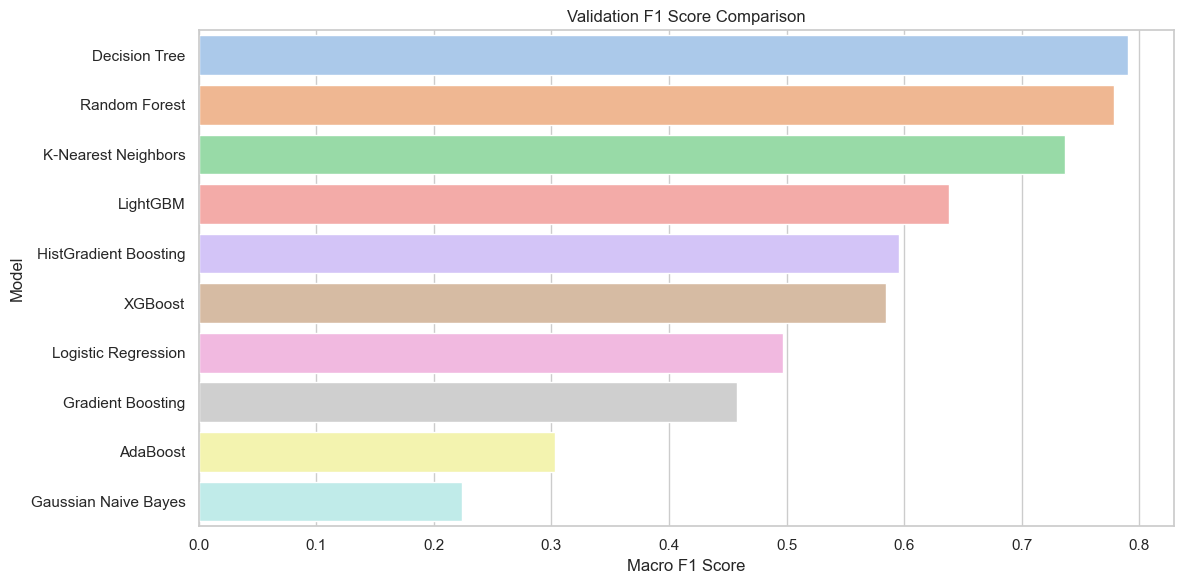

In [65]:
# Plot Validation F1 Score comparison

plt.figure(figsize=(12, 6))

sns.barplot(
    data=results_df,
    x="Validation F1",
    y="Model",
    palette="pastel"
)

plt.title("Validation F1 Score Comparison")

plt.xlabel("Macro F1 Score")

plt.ylabel("Model")

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "validation_f1_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

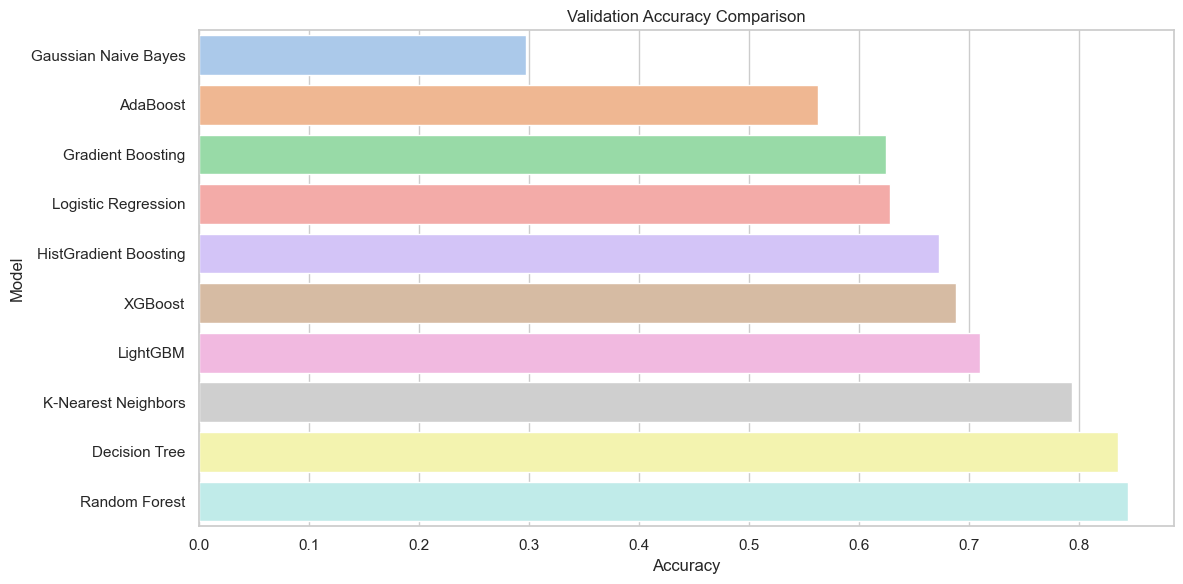

In [66]:
# Plot Validation Accuracy comparison

plt.figure(figsize=(12, 6))

plot_df = results_df.sort_values(
    by="Validation Accuracy",
    ascending=True
)

sns.barplot(
    data=plot_df,
    x="Validation Accuracy",
    y="Model",
    palette="pastel"
)

plt.title("Validation Accuracy Comparison")

plt.xlabel("Accuracy")

plt.ylabel("Model")

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "validation_accuracy_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

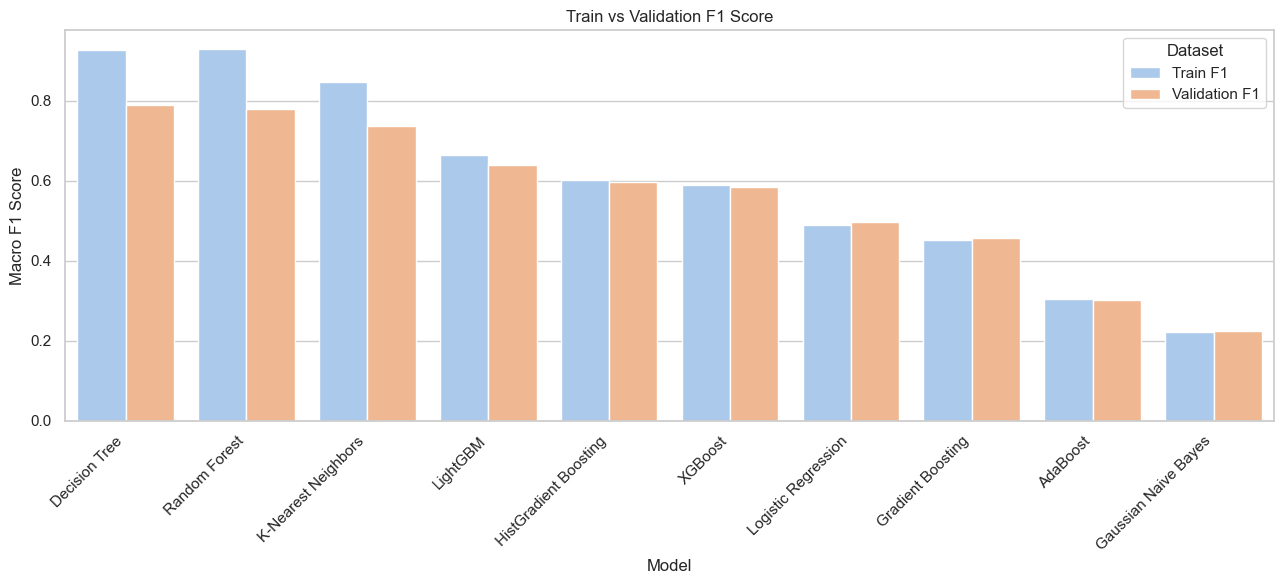

In [67]:
# Compare Train vs Validation F1 Score

comparison = results_df.melt(

    id_vars="Model",

    value_vars=[

        "Train F1",

        "Validation F1"

    ],

    var_name="Dataset",

    value_name="F1 Score"

)

plt.figure(figsize=(13,6))

sns.barplot(

    data=comparison,

    x="Model",

    y="F1 Score",

    hue="Dataset",

    palette="pastel"

)

plt.xticks(rotation=45, ha="right")

plt.title("Train vs Validation F1 Score")

plt.xlabel("Model")

plt.ylabel("Macro F1 Score")

plt.tight_layout()

plt.savefig(

    FIGURE_DIR / "train_validation_f1.png",

    dpi=300,

    bbox_inches="tight"

)

plt.show()

## Model Performance Comparison


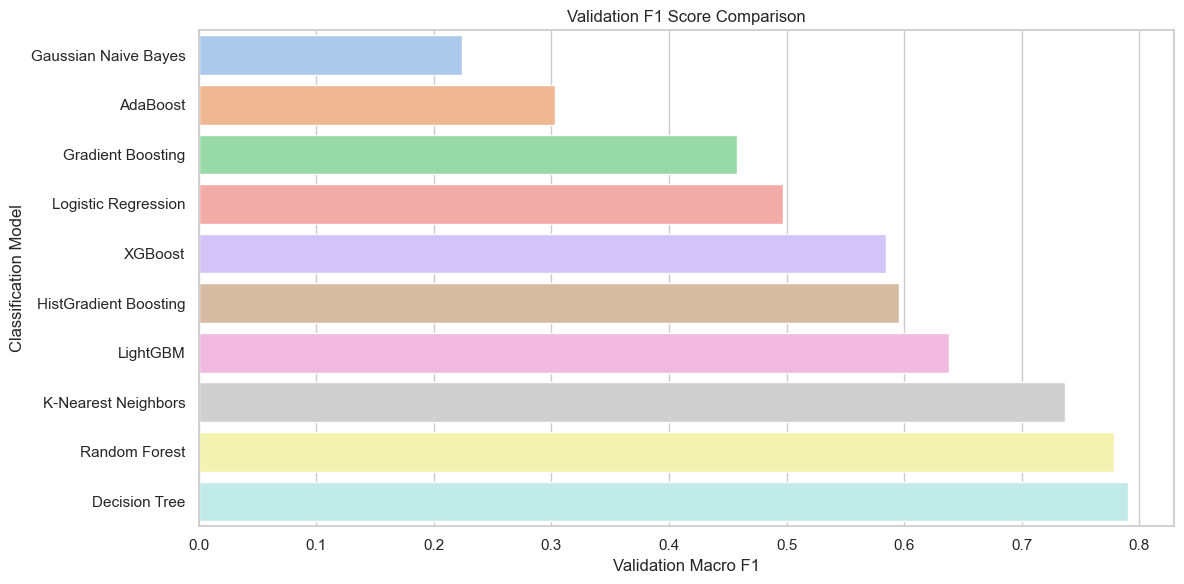

In [68]:
# Compare Validation F1 Score across models

plt.figure(figsize=(12, 6))

plot_df = results_df.sort_values(
    "Validation F1"
)

sns.barplot(
    data=plot_df,
    x="Validation F1",
    y="Model",
    palette="pastel"
)

plt.title("Validation F1 Score Comparison")

plt.xlabel("Validation Macro F1")

plt.ylabel("Classification Model")

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "validation_f1_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

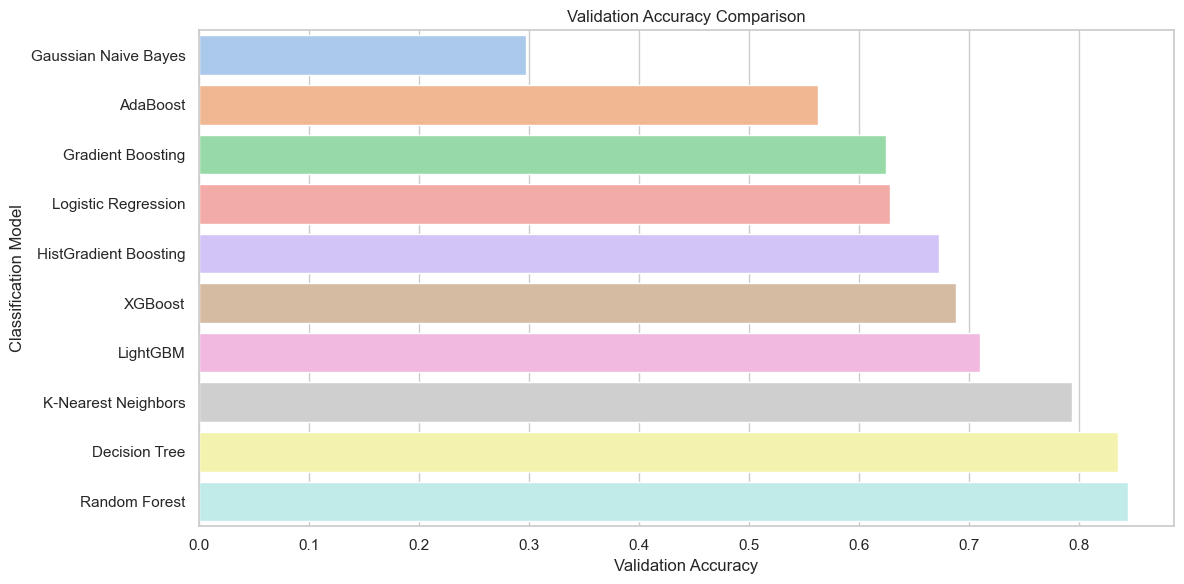

In [69]:
# Compare Validation Accuracy across models

plt.figure(figsize=(12,6))

plot_df = results_df.sort_values(
    "Validation Accuracy"
)

sns.barplot(
    data=plot_df,
    x="Validation Accuracy",
    y="Model",
    palette="pastel"
)

plt.title("Validation Accuracy Comparison")

plt.xlabel("Validation Accuracy")

plt.ylabel("Classification Model")

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "validation_accuracy_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

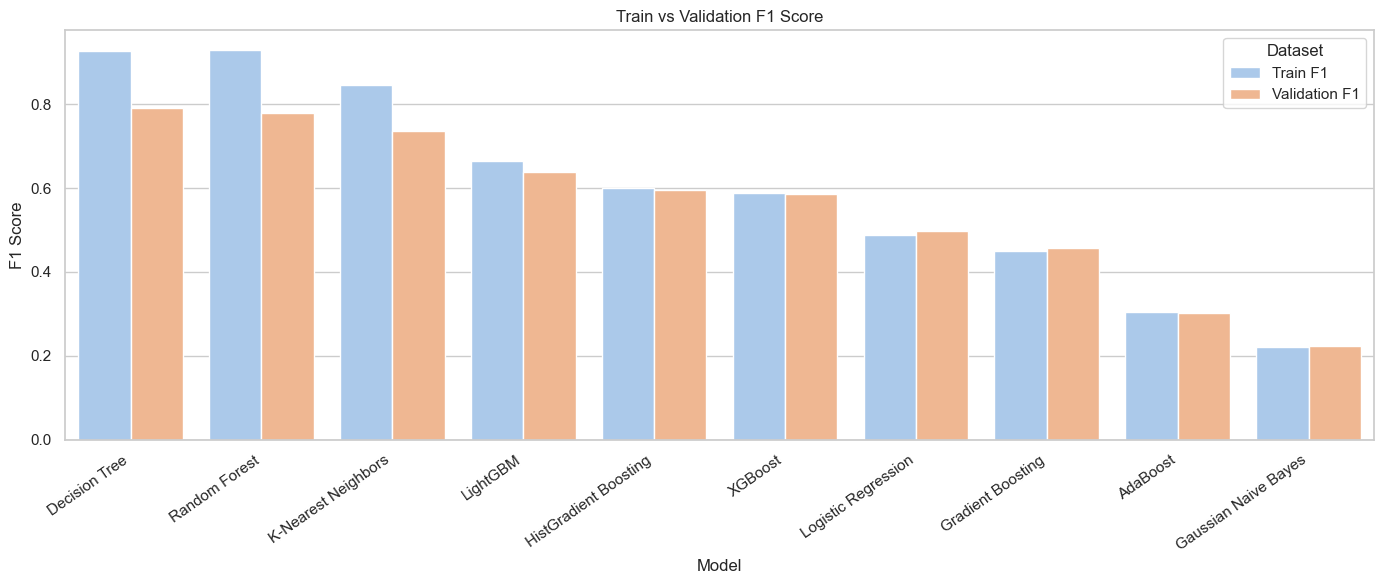

In [70]:
# Compare Train vs Validation F1 Score

comparison = results_df.melt(

    id_vars="Model",

    value_vars=[
        "Train F1",
        "Validation F1"
    ],

    var_name="Dataset",

    value_name="F1 Score"

)

plt.figure(figsize=(14,6))

sns.barplot(

    data=comparison,

    x="Model",

    y="F1 Score",

    hue="Dataset",

    palette="pastel"

)

plt.xticks(
    rotation=35,
    ha="right"
)

plt.title("Train vs Validation F1 Score")

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "train_vs_validation_f1.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

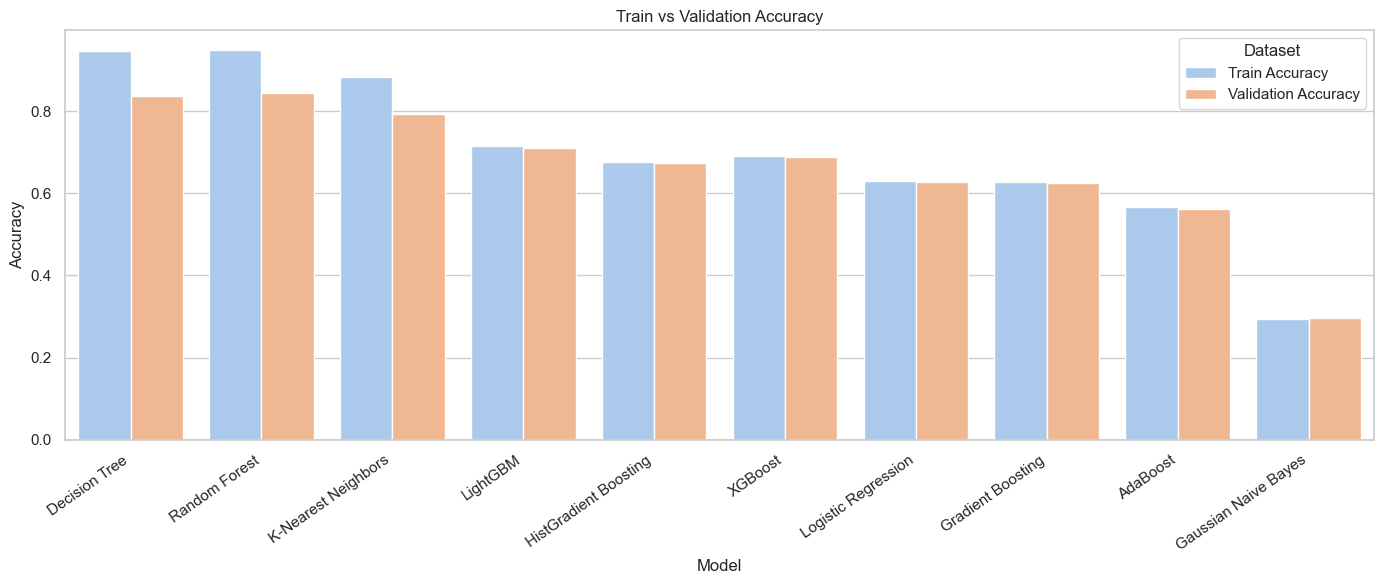

In [71]:
# Compare Train vs Validation Accuracy

comparison = results_df.melt(

    id_vars="Model",

    value_vars=[
        "Train Accuracy",
        "Validation Accuracy"
    ],

    var_name="Dataset",

    value_name="Accuracy"

)

plt.figure(figsize=(14,6))

sns.barplot(

    data=comparison,

    x="Model",

    y="Accuracy",

    hue="Dataset",

    palette="pastel"

)

plt.xticks(
    rotation=35,
    ha="right"
)

plt.title("Train vs Validation Accuracy")

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "train_vs_validation_accuracy.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Best Model Selection


In [72]:
# Select the best model

best_model_name = results_df.iloc[0]["Model"]

best_model = trained_models[best_model_name]

print(f"Best Classification Model : {best_model_name}")

Best Classification Model : Decision Tree


In [73]:
# Predict on the test dataset

test_predictions = best_model.predict(

    X_test

)

In [75]:
# Evaluate the best model on the test dataset

test_results = pd.DataFrame({

    "Metric":[
        "Accuracy",
        "Balanced Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ],

    "Value":[

        accuracy_score(y_test, test_predictions),

        balanced_accuracy_score(y_test, test_predictions),

        precision_score(
            y_test,
            test_predictions,
            average="macro",
            zero_division=0
        ),

        recall_score(
            y_test,
            test_predictions,
            average="macro",
            zero_division=0
        ),

        f1_score(
            y_test,
            test_predictions,
            average="macro",
            zero_division=0
        )

    ]

})

test_results

,Metric,Value
0,Accuracy,0.833962
1,Balanced Accuracy,0.771359
2,Precision,0.795117
3,Recall,0.771359
4,F1 Score,0.782704


In [76]:
# Save test evaluation results

test_results.to_csv(

    TABLE_DIR / "best_model_test_results.csv",

    index=False

)

print("Test evaluation results saved successfully.")

Test evaluation results saved successfully.


In [77]:
# Classification Report

print(
    classification_report(
        y_test,
        test_predictions,
        target_names=label_encoder.classes_,
        zero_division=0
    )
)

                     precision    recall  f1-score   support

               Good       0.86      0.85      0.86     20341
          Hazardous       0.79      0.73      0.76       245
           Moderate       0.86      0.88      0.87     58061
          Unhealthy       0.84      0.83      0.84     19508
Unhealthy_Sensitive       0.75      0.74      0.74     26230
     Very_Unhealthy       0.67      0.60      0.63      1562

           accuracy                           0.83    125947
          macro avg       0.80      0.77      0.78    125947
       weighted avg       0.83      0.83      0.83    125947



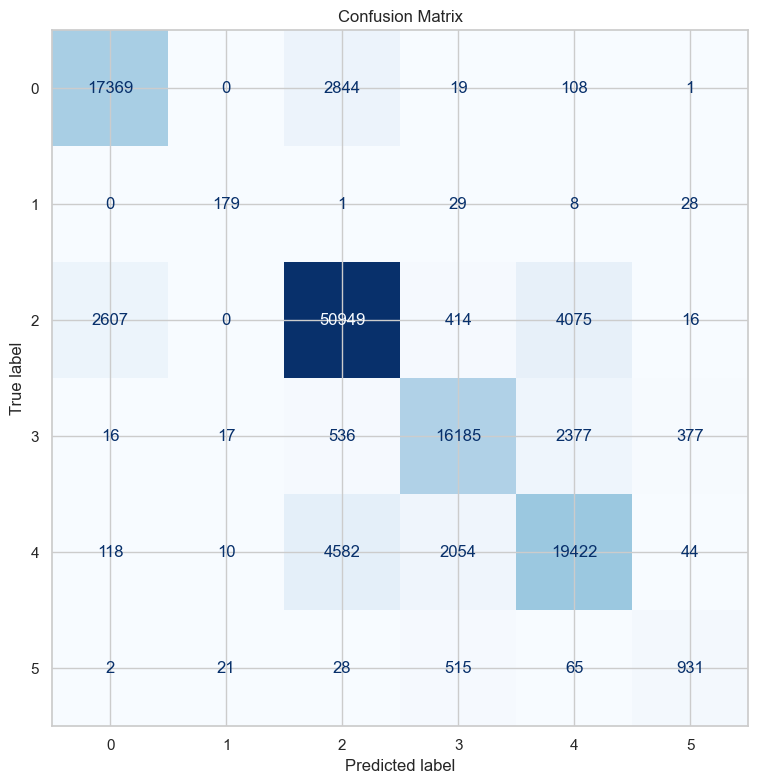

In [78]:
# Confusion Matrix

fig, ax = plt.subplots(figsize=(10,8))

ConfusionMatrixDisplay.from_predictions(

    y_test,

    test_predictions,

    cmap="Blues",

    ax=ax,

    colorbar=False

)

plt.title("Confusion Matrix")

plt.tight_layout()

plt.savefig(

    FIGURE_DIR / "confusion_matrix.png",

    dpi=300,

    bbox_inches="tight"

)

plt.show()

## Cross Validation


In [80]:
# Perform Stratified K-Fold Cross Validation

cv = StratifiedKFold(

    n_splits=3,

    shuffle=True,

    random_state=RANDOM_STATE

)

cv_scores = cross_val_score(

    best_model,

    X,

    y,

    cv=cv,

    scoring="f1_macro",

    n_jobs=-1

)

In [81]:
# Cross Validation Summary

cv_results = pd.DataFrame({

    "Fold":[

        f"Fold {i}"

        for i in range(

            1,

            len(cv_scores)+1

        )

    ],

    "Macro F1":cv_scores

})

cv_results

,Fold,Macro F1
0,Fold 1,0.777434
1,Fold 2,0.773781
2,Fold 3,0.769612


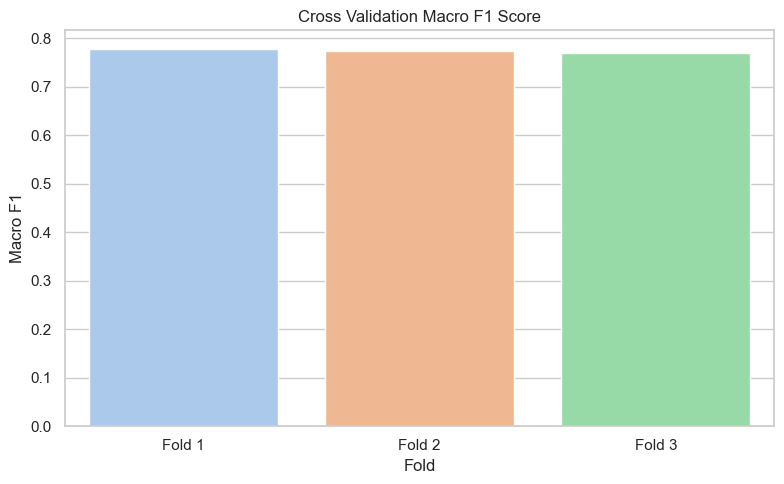

In [82]:
# Cross Validation Macro F1

plt.figure(figsize=(8,5))

sns.barplot(

    data=cv_results,

    x="Fold",

    y="Macro F1",

    palette="pastel"

)

plt.title("Cross Validation Macro F1 Score")

plt.tight_layout()

plt.savefig(

    FIGURE_DIR / "cross_validation_f1.png",

    dpi=300,

    bbox_inches="tight"

)

plt.show()

In [83]:
# Average Cross Validation Performance

print(

    f"Average CV Macro F1 : {cv_scores.mean():.4f}"

)

print(

    f"Standard Deviation : {cv_scores.std():.4f}"

)

Average CV Macro F1 : 0.7736
Standard Deviation : 0.0032


## Save Final Model and Predictions

In [84]:
# Save the best model

joblib.dump(

    best_model,

    MODEL_DIR / "best_classification_model.pkl"

)

print("Best model saved successfully.")

Best model saved successfully.


In [85]:
# Save predictions

prediction_df = pd.DataFrame({

    "Actual Category": y_test,

    "Predicted Category": test_predictions

})

prediction_df.to_csv(

    TABLE_DIR / "test_predictions_classification.csv",

    index=False

)

prediction_df.head()

,Actual Category,Predicted Category
0,2,2
1,2,2
2,4,4
3,2,0
4,2,2


## Initial Findings

In [86]:
# Summary

summary = pd.DataFrame({

    "Metric":[

        "Best Model",

        "Validation Accuracy",

        "Validation F1",

        "Test Accuracy",

        "Test F1",

        "Average CV F1"

    ],

    "Value":[

        best_model_name,

        results_df.iloc[0]["Validation Accuracy"],

        results_df.iloc[0]["Validation F1"],

        test_results.loc[
            test_results["Metric"]=="Accuracy",
            "Value"
        ].values[0],

        test_results.loc[
            test_results["Metric"]=="F1 Score",
            "Value"
        ].values[0],

        cv_scores.mean()

    ]

})

summary

,Metric,Value
0,Best Model,Decision Tree
1,Validation Accuracy,0.83532
2,Validation F1,0.789945
3,Test Accuracy,0.833962
4,Test F1,0.782704
5,Average CV F1,0.773609


In [87]:
# Save summary

summary.to_csv(

    TABLE_DIR / "classification_summary.csv",

    index=False

)

print("Summary saved successfully.")

Summary saved successfully.


In [88]:
# Save final optimization dataset

final_df = X.copy()

final_df[CLASSIFICATION_TARGET] = label_encoder.inverse_transform(
    y
)

final_df.to_parquet(

    DATA_DIR / "processed" / "airintel_ml_final.parquet",

    index=False

)

print("Final dataset saved successfully.")

print(f"Dataset Shape : {final_df.shape}")

Final dataset saved successfully.
Dataset Shape : (839644, 73)


In [89]:
# Save final optimization dataset

final_columns = [

    "US_AQI",

    "AQI_Category",

    "Absolute_Latitude",
    "City",
    "Cloud_Cover_Percent",
    "Cloud_High_Percent",
    "Cloud_Low_Percent",
    "Cloud_Mid_Percent",
    "Coastal_State",
    "Crop_Burning_Season",
    "Day",
    "Day_of_Month",
    "Day_of_Week",
    "Day_of_Year",
    "Days_in_Month",
    "Dew_Point_C",
    "Diffuse_Radiation_Wm2",
    "Direct_Radiation_Wm2",
    "Dry_Day",
    "Festival_Period",
    "Heavy_Cloud",
    "Heavy_Rain",
    "High_Wind",
    "Hour",
    "Hour_Cos",
    "Hour_Sin",
    "Humidity_Category",
    "Humidity_Percent",
    "Inland_State",
    "Is_Daytime",
    "Is_Month_End",
    "Is_Month_Start",
    "Is_Quarter_End",
    "Is_Quarter_Start",
    "Is_Raining",
    "Is_Weekend",
    "Lat_Long_Interaction",
    "Latitude",
    "Latitude_Band",
    "Longitude",
    "Longitude_Band",
    "Month",
    "Month_Cos",
    "Month_Sin",
    "Northern_India",
    "Precipitation_mm",
    "Pressure_Difference",
    "Pressure_MSL_hPa",
    "Quarter",
    "Rain_mm",
    "Season",
    "Solar_Radiation_Wm2",
    "State",
    "Sunshine_Seconds",
    "Surface_Pressure_hPa",
    "Temp_2m_C",
    "Temp_Dew_Diff",
    "Temp_Humidity",
    "Temp_Inversion",
    "Temp_Wind",
    "Time_of_Day",
    "Weather_Stress_Index",
    "Week",
    "Week_of_Month",
    "Week_of_Year",
    "Weekday_Cos",
    "Weekday_Sin",
    "Wind_Category",
    "Wind_Dir_10m",
    "Wind_Gust_Ratio",
    "Wind_Gusts_kmh",
    "Wind_Speed_10m_kmh",
    "Wind_Stagnation",
    "Year"

]

final_dataset = df_ml[final_columns].copy()

final_dataset.to_parquet(

    DATA_DIR / "processed" / "airintel_ml_final.parquet",

    index=False

)

print("Final optimization dataset saved successfully.")

print(f"Shape : {final_dataset.shape}")

Final optimization dataset saved successfully.
Shape : (839644, 74)


In [90]:
# Save selected features

selected_features = [

    col for col in final_dataset.columns

    if col not in [

        "US_AQI",

        "AQI_Category"

    ]

]

joblib.dump(

    selected_features,

    MODEL_DIR / "selected_features.pkl"

)

print(f"{len(selected_features)} selected features saved.")

72 selected features saved.


# Conclusion

The classification models were successfully trained and evaluated using the feature-engineered AirIntel dataset.

Key outcomes:

- A baseline classifier was established for comparison.
- Multiple classification algorithms were trained using a common preprocessing pipeline.
- Models were evaluated using Accuracy, Precision, Recall and Macro F1 Score.
- The best-performing classifier was selected based on Validation Macro F1 Score.
- Final evaluation was performed on the unseen test dataset.
- Stratified Cross Validation confirmed the robustness of the selected classifier.
- Trained models, predictions and evaluation results were exported for downstream analysis.

The next notebook (09_Model_Optimization.ipynb) will optimize the best-performing models using feature selection, hyperparameter tuning, CatBoost and SHAP Explainability.

In [91]:
print("Notebook 08 Completed Successfully")
print("-" * 60)

print(f"Best Model : {best_model_name}")

print(
    f"Validation F1 : {results_df.iloc[0]['Validation F1']:.4f}"
)

print(
    f"Test Accuracy : {test_results.loc[test_results['Metric']=='Accuracy','Value'].values[0]:.4f}"
)

print(
    f"Test F1 : {test_results.loc[test_results['Metric']=='F1 Score','Value'].values[0]:.4f}"
)

print(
    f"Average CV F1 : {cv_scores.mean():.4f}"
)

print("-" * 60)

Notebook 08 Completed Successfully
------------------------------------------------------------
Best Model : Decision Tree
Validation F1 : 0.7899
Test Accuracy : 0.8340
Test F1 : 0.7827
Average CV F1 : 0.7736
------------------------------------------------------------
